In [10]:
" SGC model using torch geometric with Cora"
" Node2Vec model using torch geometric with Cora"
import torch
from torch_geometric.datasets import Planetoid # The citation network datasets “Cora”, “CiteSeer” and “PubMed” 
from torch_geometric.nn import SGConv # Import Node2Vec Model
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch.nn.functional as F

" **************** IMPORT DATA ********************"
dataset = Planetoid(root='data/Planetoid', name='Cora') # Load the Cora dataset
data = dataset[0] # Tensor representation of the Cora-Planetoid data
print('Cora: ', data)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

" **************** CONSTRUCT THE MODEL  ********************"
SGC_model = SGConv(in_channels= data.num_features, # Number of features
                   out_channels= dataset.num_classes, # Dimension of embedding
                   K = 1, cached =True)

" **************** GET EMBEDDING  ********************"
print(" Shape of the original data: ", data.x.shape)
print(" Shape of the embedding data: ", SGC_model(data.x,data.edge_index).shape)


" **************** CONSTRUCT THE MODEL FOR CLASSIFICATION  ********************"
class SGCNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = SGConv(in_channels= data.num_features, # Number of features
                   out_channels= dataset.num_classes, # Dimension of embedding
                   K = 1, cached =True)

    def forward(self):
        x = self.conv1(data.x,  data.edge_index) #Applying convolution to data
        
        # computation of log softmax
        return F.log_softmax(x, dim=1)
    

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SGC_model, data = SGCNet().to(device), data.to(device)
optimizer = torch.optim.Adam(SGC_model.parameters(), lr=0.2, weight_decay=0.005)

# What are the learning parameters:
for i, parameter in SGC_model.named_parameters():
    print(" Parameter {}".format(i))
    print("Shape: ",parameter.shape)
    
    
" **************** TRAIN FUNCTION ********************"
def train():
    SGC_model.train() # Set the model.training to be True
    optimizer.zero_grad() # Reset the gradient
    predicted_y = SGC_model() # predicted y in log softmax prob
    true_y = data.y # True labels
    losses = F.nll_loss(predicted_y[data.train_mask], true_y[data.train_mask])
    losses.backward()
    optimizer.step() # Update the parameters such that is minimized the losses
    
    
" **************** TEST FUNCTION ********************"
def test():
    SGC_model.eval() # Set the model.training to be False
    logits = SGC_model() # Log prob of all data
    accs = []
    for _, mask in data('train_mask', 'val_mask', 'test_mask'):
        pred = logits[mask].max(1)[1] #Transforming log prob to actual labels
        acc = pred.eq(data.y[mask]).sum().item() / mask.sum().item()
        accs.append(acc)
    return accs



" **************** PUTTING IT ALL TOGETHER ********************"
best_val_acc = test_acc = 0
for epoch in range(1, 101):
    train()
    train_acc, val_acc, tmp_test_acc = test()
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        test_acc = tmp_test_acc
    log = 'Epoch: {:03d}, Train: {:.4f}, Val: {:.4f}, Test: {:.4f}'
    print(log.format(epoch, train_acc, best_val_acc, test_acc))

Cora:  Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
 Shape of the original data:  torch.Size([2708, 1433])
 Shape of the embedding data:  torch.Size([2708, 7])
 Parameter conv1.lin.weight
Shape:  torch.Size([7, 1433])
 Parameter conv1.lin.bias
Shape:  torch.Size([7])
Epoch: 001, Train: 0.9857, Val: 0.6460, Test: 0.6740
Epoch: 002, Train: 0.9929, Val: 0.7200, Test: 0.7620
Epoch: 003, Train: 1.0000, Val: 0.7240, Test: 0.7640
Epoch: 004, Train: 1.0000, Val: 0.7280, Test: 0.7430
Epoch: 005, Train: 1.0000, Val: 0.7280, Test: 0.7430
Epoch: 006, Train: 1.0000, Val: 0.7280, Test: 0.7430
Epoch: 007, Train: 1.0000, Val: 0.7280, Test: 0.7430
Epoch: 008, Train: 1.0000, Val: 0.7340, Test: 0.7650
Epoch: 009, Train: 0.9929, Val: 0.7340, Test: 0.7650
Epoch: 010, Train: 1.0000, Val: 0.7420, Test: 0.7690
Epoch: 011, Train: 1.0000, Val: 0.7460, Test: 0.7740
Epoch: 012, Train: 1.0000, Val: 0.7460, Test: 0.7740
Epoch: 013, Train: 1.0000, Val: 0

Simple Graph Convolution (SGC) - Code Summary

Workflow

```
Cora Dataset
     │
     ▼
Load Graph (Nodes + Features + Edges + Labels)
     │
     ▼
SGConv Layer
     │
     ▼
Neighbor Feature Averaging (K = 1)
     │
     ▼
Linear Transformation (Learnable Weights)
     │
     ▼
Log Softmax
     │
     ▼
Loss Calculation (Training Nodes Only)
     │
     ▼
Backpropagation (Update Weights)
     │
     ▼
Evaluate on Train / Validation / Test
```

What each part does

- **Load Cora Dataset** → Loads node features (`data.x`), graph connections (`edge_index`), and labels (`data.y`).
- **SGConv Layer** → Performs graph convolution by averaging neighboring node features and applying a learnable weight matrix.
- **K = 1** → Aggregate information from **1-hop neighbors** only. How many passes of feature aggregation to be done.
- **cached=True** → Computes graph propagation once and reuses it every epoch, making SGC very fast.
- **Forward Pass** → Produces class scores for every node.
- **Log Softmax** → Converts scores into log probabilities.
- **NLL Loss** → Computes loss only on training nodes (`train_mask`).
- **Optimizer (Adam)** → Updates only the learnable weight matrix.
- **Test Function** → Computes Train, Validation, and Test accuracy.

---

Why didn't we use DeepWalk / Node2Vec?

For the **Cora dataset**, every node already has **1433 meaningful features** (Bag-of-Words representation of research papers).

- **DeepWalk / Node2Vec** are mainly used when **node features are missing**. They generate embeddings using only the graph structure (random walks).
- **SGC** directly uses the existing node features and improves them by averaging information from neighboring nodes.
- Therefore, using DeepWalk or Node2Vec here would be unnecessary because **Cora already provides rich node features**.

**In short:**

- **No node features →** Use **DeepWalk / Node2Vec** to create embeddings.
- **Good node features available (like Cora) →** Use **SGC/GCN** to propagate and improve those features.

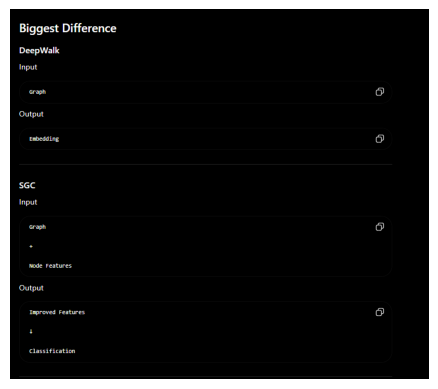

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

# Open the image
img = Image.open("SGC.png")

# Display the image inside the plot viewer
plt.imshow(img)
plt.axis("off")  # Optional: Hides the pixel coordinate axes
plt.show()


Below, we are predicting one single paper from the graph from it's ID

***Also if we want to predict a paper which is not in the graph, first we have to include that paper in the graph as a node. If a new node is added, we generally do not retrain the SGC model. We only recompute the graph propagation using the updated graph and then use the already learned weight matrix (Θ) to predict the new node.***

In [12]:
SGC_model.eval()

paper_id = 200

with torch.no_grad():
    logits = SGC_model()

predicted_class = logits[paper_id].argmax().item()
true_class = data.y[paper_id].item()
probabilities = torch.exp(logits[paper_id])

print(f"Paper ID        : {paper_id}")
print(f"Predicted Class : {predicted_class}")
print(f"Actual Class    : {true_class}")
print(f"Probabilities   : {probabilities}")

Paper ID        : 200
Predicted Class : 3
Actual Class    : 3
Probabilities   : tensor([0.0657, 0.2108, 0.0363, 0.3672, 0.1714, 0.0967, 0.0519])
